<a href="https://colab.research.google.com/github/Lu2077/Python-Math-s/blob/main/BiseccionMethodGraphOpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ingrese la función polinómica en términos de 'x': x^3+2*x
Ingresa la cantidad de iteraciones: 5


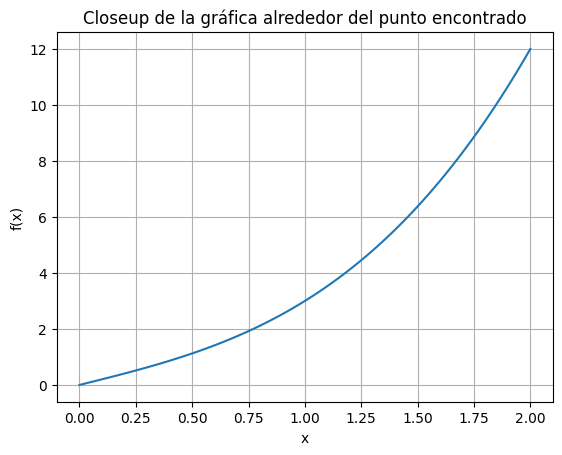

   Iteracion   xl   xu   xr    ea%
0        1.0 -2.0  2.0  0.0  100.0


In [ ]:
import sympy as sp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to be evaluated
x = sp.symbols('x')

func_str  = input("Ingrese la función polinómica en términos de 'x': ")
iteracion = input("Ingresa la cantidad de iteraciones: ")




# Bisection method
from sympy import N

def Bisec(func, xl, xu, es):
    itera = 0
    m_itera = np.array([])  # Matrix to store iteration values
    m_xl = np.array([])     # Matrix to store xl values
    m_xu = np.array([])     # Matrix to store xu values
    xr = 0
    m_xr = np.array([])     # Matrix to store xr values
    ea = 100
    m_ea = np.array([])     # Matrix to store ea values
    func = sp.sympify(func_str)
    fl = func.evalf(subs={x: xl})  # Evaluate the function at xl

    # Main loop
    while ea > es:
        xanterior = xr
        xr = (xl + xu) / 2
        fr = func.evalf(subs={x: xr})
        itera += 1
        if xr != 0:
            ea = abs((xr - xanterior) / xr) * 100
        test = fl * fr

        # Append values to matrices
        m_itera = np.append(m_itera, itera)
        m_xl = np.append(m_xl, xl)
        m_xu = np.append(m_xu, xu)
        m_xr = np.append(m_xr, xr)
        m_ea = np.append(m_ea, ea)

        if test < 0:
            xu = xr
        elif test > 0:
            xl = xr
            fl = fr
        else:
            ea = 0

    # Represent data in pandas DataFrame
    iteracion = pd.Series(m_itera, name="Iteracion")
    xl = pd.Series(m_xl, name="xl")
    xu = pd.Series(m_xu, name="xu")
    xr = pd.Series(m_xr, name="xr")
    ea = pd.Series(m_ea, name="ea%")
    tabla = pd.concat([iteracion, xl, xu, xr, ea], axis=1)  # Concatenate columns

    # Plot closeup
    xr = m_xr[-1]
    xu = m_xu[-1]
    ea = m_ea[-1]
    x_vals_closeup = np.linspace(xr, xu, int(ea))
    y_vals_closeup = [func.evalf(subs={x: val}) for val in x_vals_closeup]

    plt.plot(x_vals_closeup, y_vals_closeup)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Closeup de la gráfica alrededor del punto encontrado')
    plt.grid(True)
    plt.show()

    return tabla

a = Bisec(func_str, -2, 2, 0.01)
print(a)